In [9]:
# Imports
import re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import mannwhitneyu

In [10]:
# Load
SEED = 123
df = pd.read_csv("../Dati/Processed/dataset_processed_quantile1_sentences.csv")
X, y = df[["text_bert"]], df["binary_label"].values
groups = df["topic_id"].values  # keep triplets together across splits

In [11]:
# Explicit stylometric features (all named -> interpretable coefficients)
FP = {"i","me","my","mine","we","us","our","ours"}
TP = {"he","him","his","she","her","hers","they","them","their","theirs"}
P2 = {"you","your","yours"}
STYLE_NAMES = ["1st-person","2nd-person","3rd-person","exclamation","question",
               "parentheses","quotes","dashes","ALL-CAPS","avg word len","avg sent len","type-token ratio"]

def style_matrix(frame):
    rows = []
    for t in frame["text_bert"]:
        tok = re.findall(r"[A-Za-z']+", t); low = [w.lower() for w in tok]; n = max(len(tok), 1)
        sents = [s for s in re.split(r"[.!?]+", t) if s.strip()]; ns = max(len(sents), 1)
        rows.append([
            sum(w in FP for w in low)/n*1000, sum(w in P2 for w in low)/n*1000, sum(w in TP for w in low)/n*1000,
            t.count("!")/n*1000, t.count("?")/n*1000, (t.count("(")+t.count(")"))/n*1000,
            (t.count(chr(34))+t.count(chr(8220))+t.count(chr(8221)))/n*1000,
            (t.count("-")+t.count(chr(8211))+t.count(chr(8212)))/n*1000,
            sum(1 for w in tok if len(w) > 1 and w.isupper())/n,
            np.mean([len(w) for w in tok]) if tok else 0, n/ns, len(set(low))/n,
        ])
    return np.array(rows)

In [12]:
# Pipeline + nested grid search
# char TF-IDF (sparse) + standardized style block (dense); both refit per fold -> no leakage
feats = ColumnTransformer([
    ("char", TfidfVectorizer(min_df=0.025, sublinear_tf=True), "text_bert"),
    ("style", Pipeline([("f", FunctionTransformer(style_matrix)), ("s", StandardScaler())]), ["text_bert"]),
])
pipe = Pipeline([("feats", feats),
                 ("clf", LinearSVC(class_weight="balanced", random_state=SEED, max_iter=8000))])

# analyzer + range chosen by CV (unigram/bigram-only ranges underperform ~0.58-0.62, tested apart)
grid = {
    "feats__char__analyzer": ["char", "char_wb"],
    "feats__char__ngram_range": [(1,2),(2,3),(2, 4), (2, 6)],
    "clf__C": [0.5, 1.0],  # kept <=1.0 to avoid low-regularization overfit
}

outer = StratifiedGroupKFold(n_splits=5)
inner = StratifiedGroupKFold(n_splits=5)

gs = GridSearchCV(pipe, grid, scoring="f1_macro", cv=inner, n_jobs=-1)
nested = cross_val_score(gs, X, y, groups=groups, scoring="f1_macro", cv=outer, params={"groups": groups})
print(f"nested f1_macro = {nested.mean():.4f} ± {nested.std():.4f}")

nested f1_macro = 0.6656 ± 0.0242


In [13]:
# Best config + OOF predictions (same group-aware folds)
gs = GridSearchCV(pipe, grid, scoring="f1_macro", cv=outer, n_jobs=-1).fit(X, y, groups=groups)
print(gs.best_params_)
oof = cross_val_predict(gs.best_estimator_, X, y, cv=outer, groups=groups)

{'clf__C': 1.0, 'feats__char__analyzer': 'char', 'feats__char__ngram_range': (2, 6)}


In [14]:
# Classification report + confusion matrix
print(classification_report(y, oof, digits=3))
print(confusion_matrix(y, oof))

              precision    recall  f1-score   support

           0      0.629     0.481     0.545       208
           1      0.768     0.858     0.810       416

    accuracy                          0.732       624
   macro avg      0.698     0.669     0.678       624
weighted avg      0.721     0.732     0.722       624

[[100 108]
 [ 59 357]]


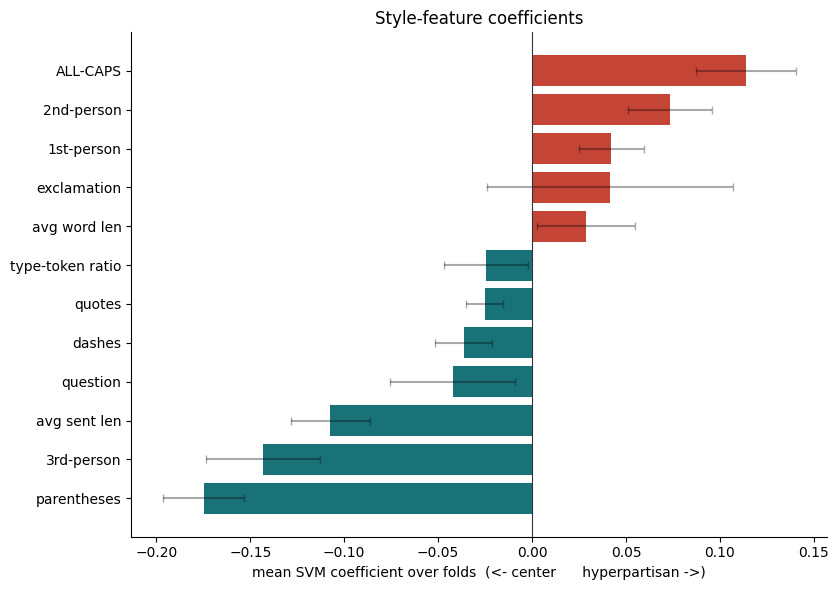

In [15]:
# Interpretation: style-feature coefficients, aggregated over folds (mean +/- std)
# style block = last 12 columns of clf.coef_
best = clone(pipe).set_params(**gs.best_params_)
coefs = []
for tr, _ in outer.split(X, y, groups):
    best.fit(X.iloc[tr], y[tr])
    coefs.append(best.named_steps["clf"].coef_[0][-12:])
coefs = np.vstack(coefs); mean, std = coefs.mean(0), coefs.std(0)
order = np.argsort(mean)
col = ["#197278" if mean[i] < 0 else "#c44536" for i in order]

plt.figure(figsize=(8.5, 6))
plt.barh(range(12), mean[order], xerr=std[order], color=col, ecolor="#00000055", capsize=3)
plt.yticks(range(12), [STYLE_NAMES[i] for i in order])
plt.axvline(0, color="#333", lw=.8)
plt.xlabel("mean SVM coefficient over folds  (<- center      hyperpartisan ->)")
plt.title("Style-feature coefficients")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

1st-person         hyp=   8.26  center=   7.25  p=0.102  
2nd-person         hyp=   3.37  center=   4.29  p=0.0304 *
3rd-person         hyp=  14.07  center=  16.87  p=0.418  
exclamation        hyp=   0.36  center=   0.21  p=0.203  
question           hyp=   0.49  center=   0.54  p=0.214  
parentheses        hyp=   4.36  center=   7.41  p=0.0309 *
quotes             hyp=  22.08  center=  20.52  p=0.267  
dashes             hyp=  14.50  center=  14.99  p=0.504  
ALL-CAPS           hyp=   0.04  center=   0.05  p=0.492  
avg word len       hyp=   4.97  center=   4.97  p=0.949  
avg sent len       hyp=  19.63  center=  20.06  p=0.722  
type-token ratio   hyp=   0.66  center=   0.68  p=0.0154 *


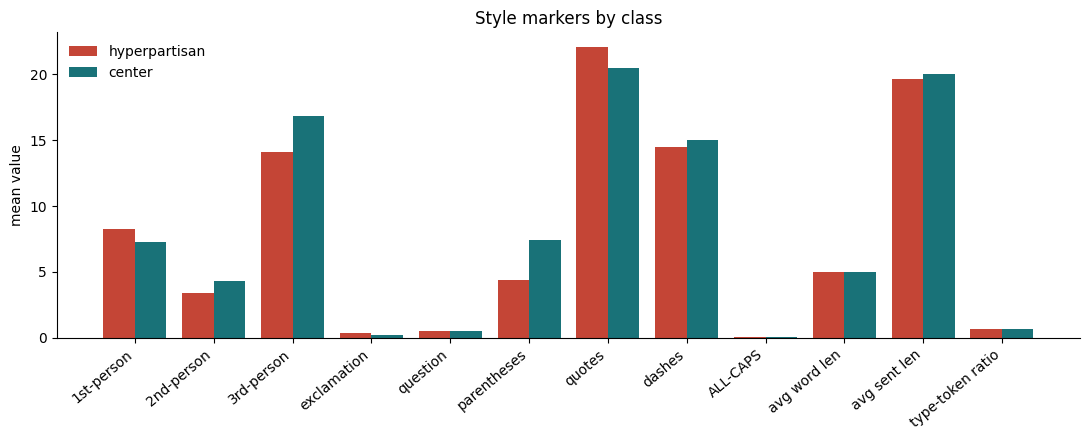

In [16]:
# Style markers by class + significance test (Mann-Whitney)
S = style_matrix(X)  # raw, unscaled
m1, m0 = S[y == 1].mean(0), S[y == 0].mean(0)
for j, name in enumerate(STYLE_NAMES):
    p = mannwhitneyu(S[y == 1, j], S[y == 0, j]).pvalue
    star = "*" if p < 0.05 else " "
    print(f"{name:18s} hyp={m1[j]:7.2f}  center={m0[j]:7.2f}  p={p:.3g} {star}")

x = np.arange(12); w = 0.4
plt.figure(figsize=(11, 4.5))
plt.bar(x - w/2, m1, w, label="hyperpartisan", color="#c44536")
plt.bar(x + w/2, m0, w, label="center", color="#197278")
plt.xticks(x, STYLE_NAMES, rotation=40, ha="right")
plt.ylabel("mean value"); plt.title("Style markers by class")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.legend(frameon=False); plt.tight_layout(); plt.show()